**Import Libraries**

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#**Get Data**

In [2]:
# Fetch Data
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")
data.reset_index(inplace=True)

[*********************100%***********************]  5 of 5 completed


**Data Preprocessing**
- Clean missing data: Handle any missing values (e.g., by forward filling or dropping them).
- Calculate returns: You can calculate daily returns (percentage change from one day to the next) using stock closing prices.

In [3]:
# Data Preprocessing
# Handling missing values
data.fillna(method='ffill', inplace=True)
# Checking for duplicates
data.drop_duplicates(inplace=True)

<ipython-input-3-afedc74c2c76>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


#**Feature Engineering**

In [8]:
# Feature Engineering
for ticker in tickers:
    data[f'{ticker}_Return'] = data['Close'][ticker].pct_change()
    data[f'{ticker}_Volatility'] = data[f'{ticker}_Return'].rolling(window=10).std()
    data[f'{ticker}_Momentum'] = data[f'{ticker}_Return'].rolling(window=5).mean()
    data[f'{ticker}_Moving_Avg'] = data['Close'][ticker].rolling(window=10).mean()
data.dropna(inplace=True)

#**Exploratory Data Analysis (EDA)**

**Linear Plot of Stock Prices**
- This plot visualizes the closing prices of the selected stocks over time.

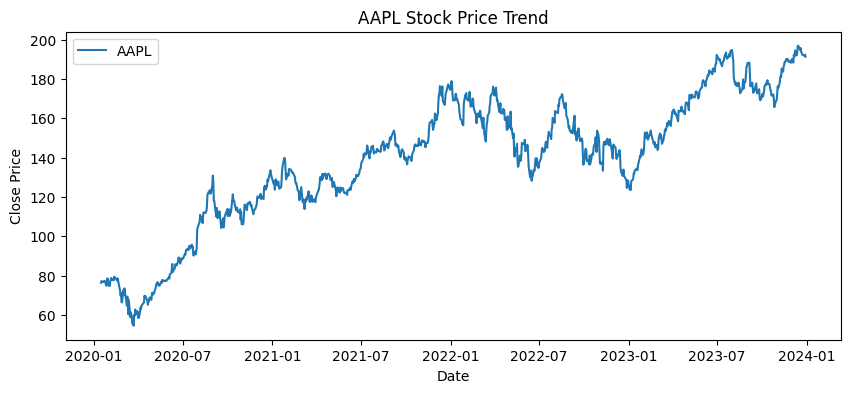

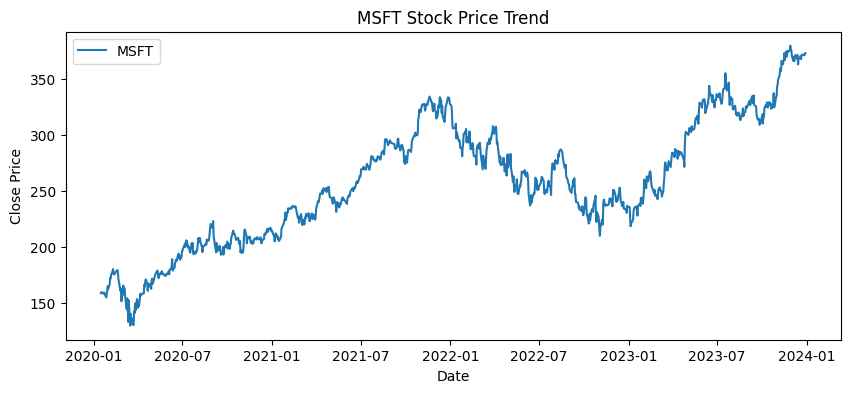

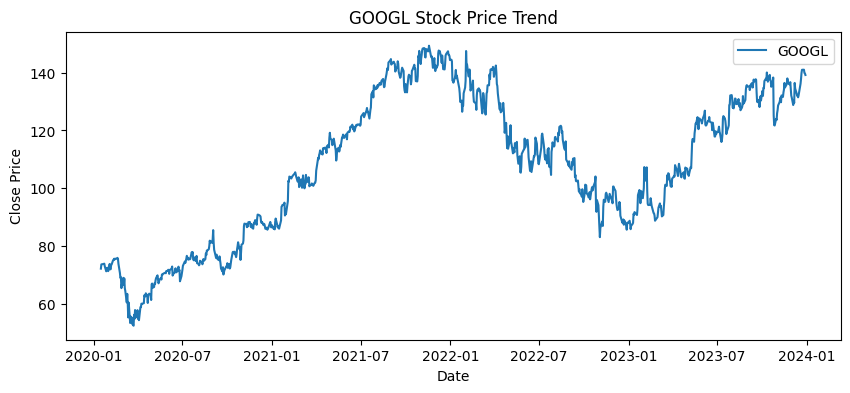

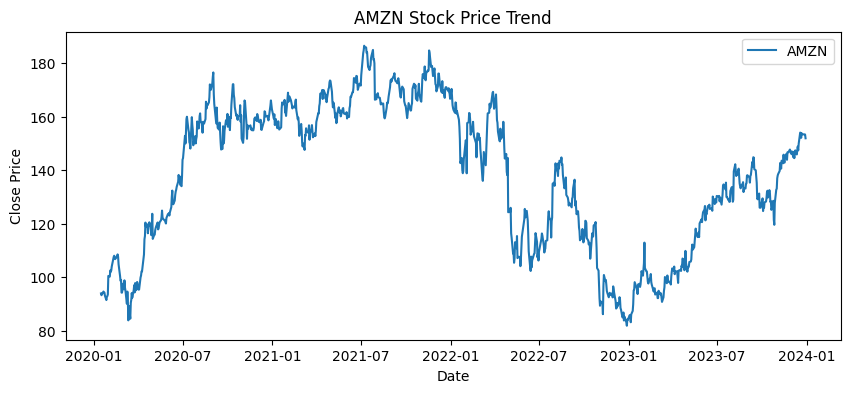

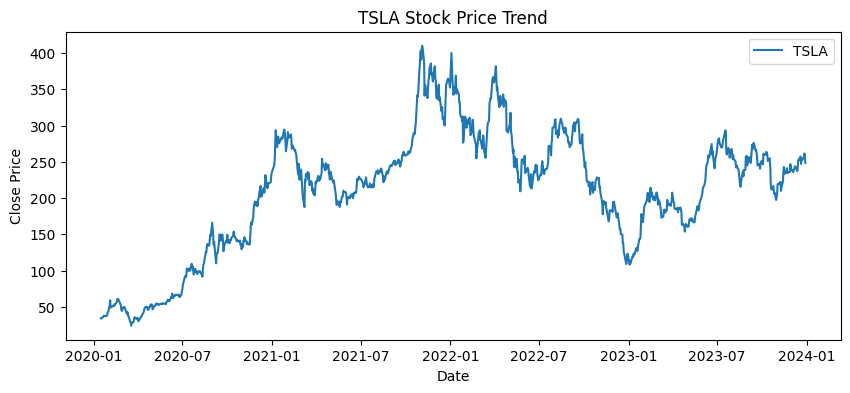

In [10]:
for ticker in tickers:
    plt.figure(figsize=(10,4))
    plt.plot(data['Date'], data['Close'][ticker], label=ticker)
    plt.title(f'{ticker} Stock Price Trend')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.show()

**Stock Returns Distribution**

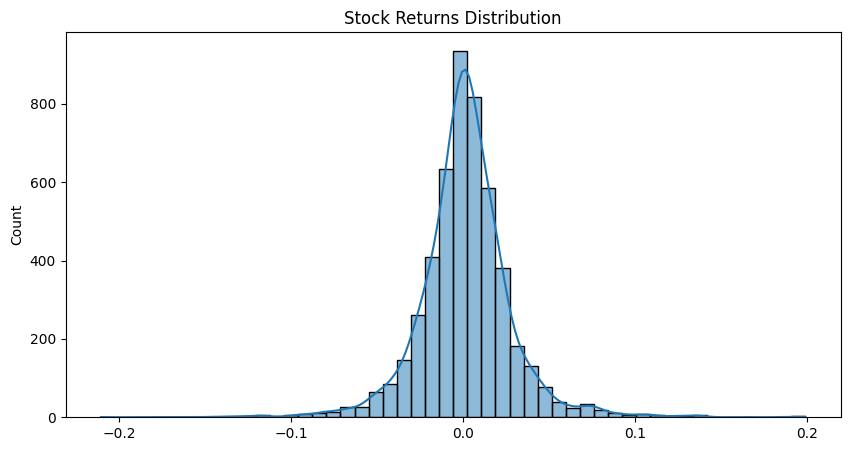

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(data[[f'{ticker}_Return' for ticker in tickers]].dropna().values.flatten(), bins=50, kde=True)
plt.title("Stock Returns Distribution")
plt.show()

**Momentum vs Return**

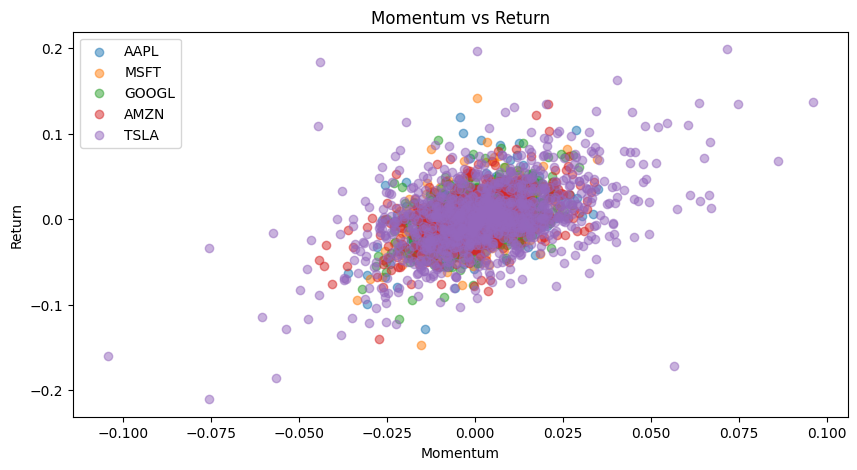

In [12]:
plt.figure(figsize=(10,5))
for ticker in tickers:
    plt.scatter(data[f'{ticker}_Momentum'], data[f'{ticker}_Return'], alpha=0.5, label=ticker)
plt.title("Momentum vs Return")
plt.xlabel("Momentum")
plt.ylabel("Return")
plt.legend()
plt.show()

**10-Day Moving Average**

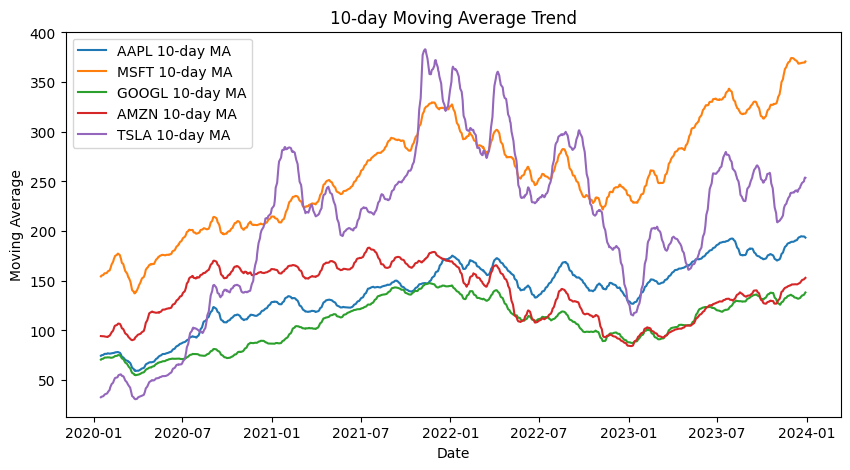

In [13]:
plt.figure(figsize=(10,5))
for ticker in tickers:
    plt.plot(data['Date'], data[f'{ticker}_Moving_Avg'], label=f'{ticker} 10-day MA')
plt.title("10-day Moving Average Trend")
plt.xlabel("Date")
plt.ylabel("Moving Average")
plt.legend()
plt.show()

**Box Plot**
- This box plot visualizes the distribution of daily returns for each stock, helping to identify outliers.

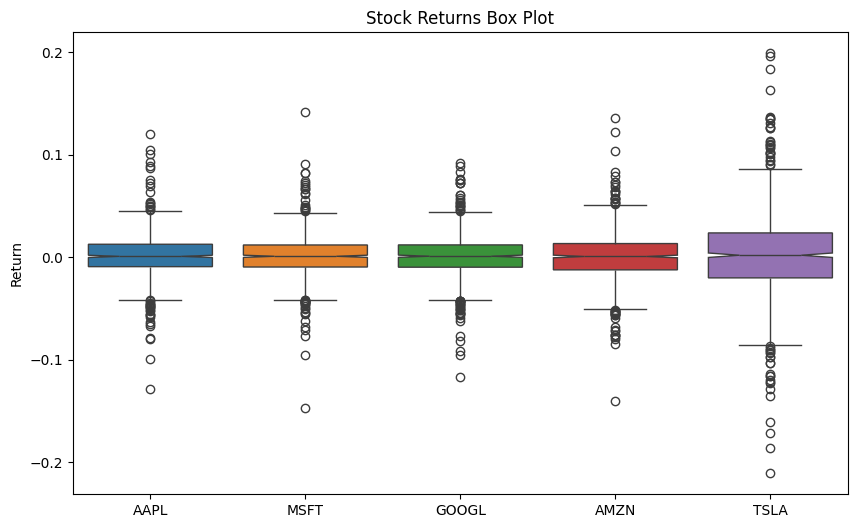

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=[data[f'{ticker}_Return'].dropna() for ticker in tickers], notch=True)
plt.xticks(ticks=range(len(tickers)), labels=tickers)
plt.title("Stock Returns Box Plot")
plt.ylabel("Return")
plt.show()

**Stock Volatility Over Time**

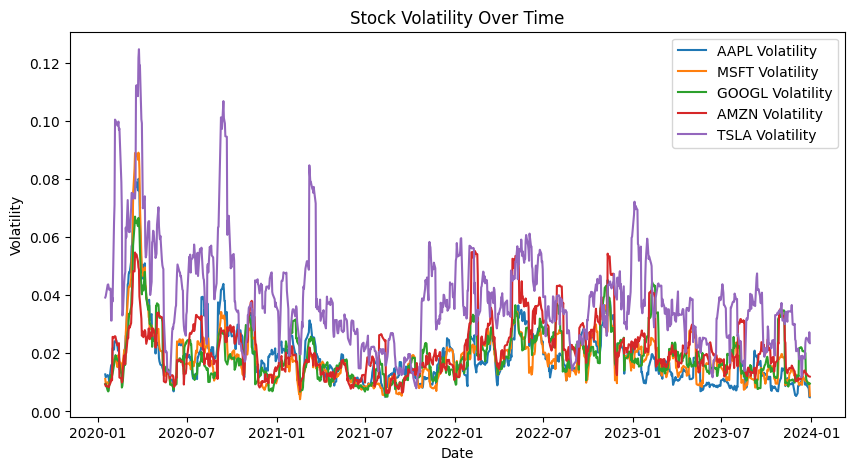

In [16]:
plt.figure(figsize=(10,5))
for ticker in tickers:
    plt.plot(data['Date'], data[f'{ticker}_Volatility'], label=f'{ticker} Volatility')
plt.title("Stock Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

**Stock Returns Pairplot**

<Figure size 1000x500 with 0 Axes>

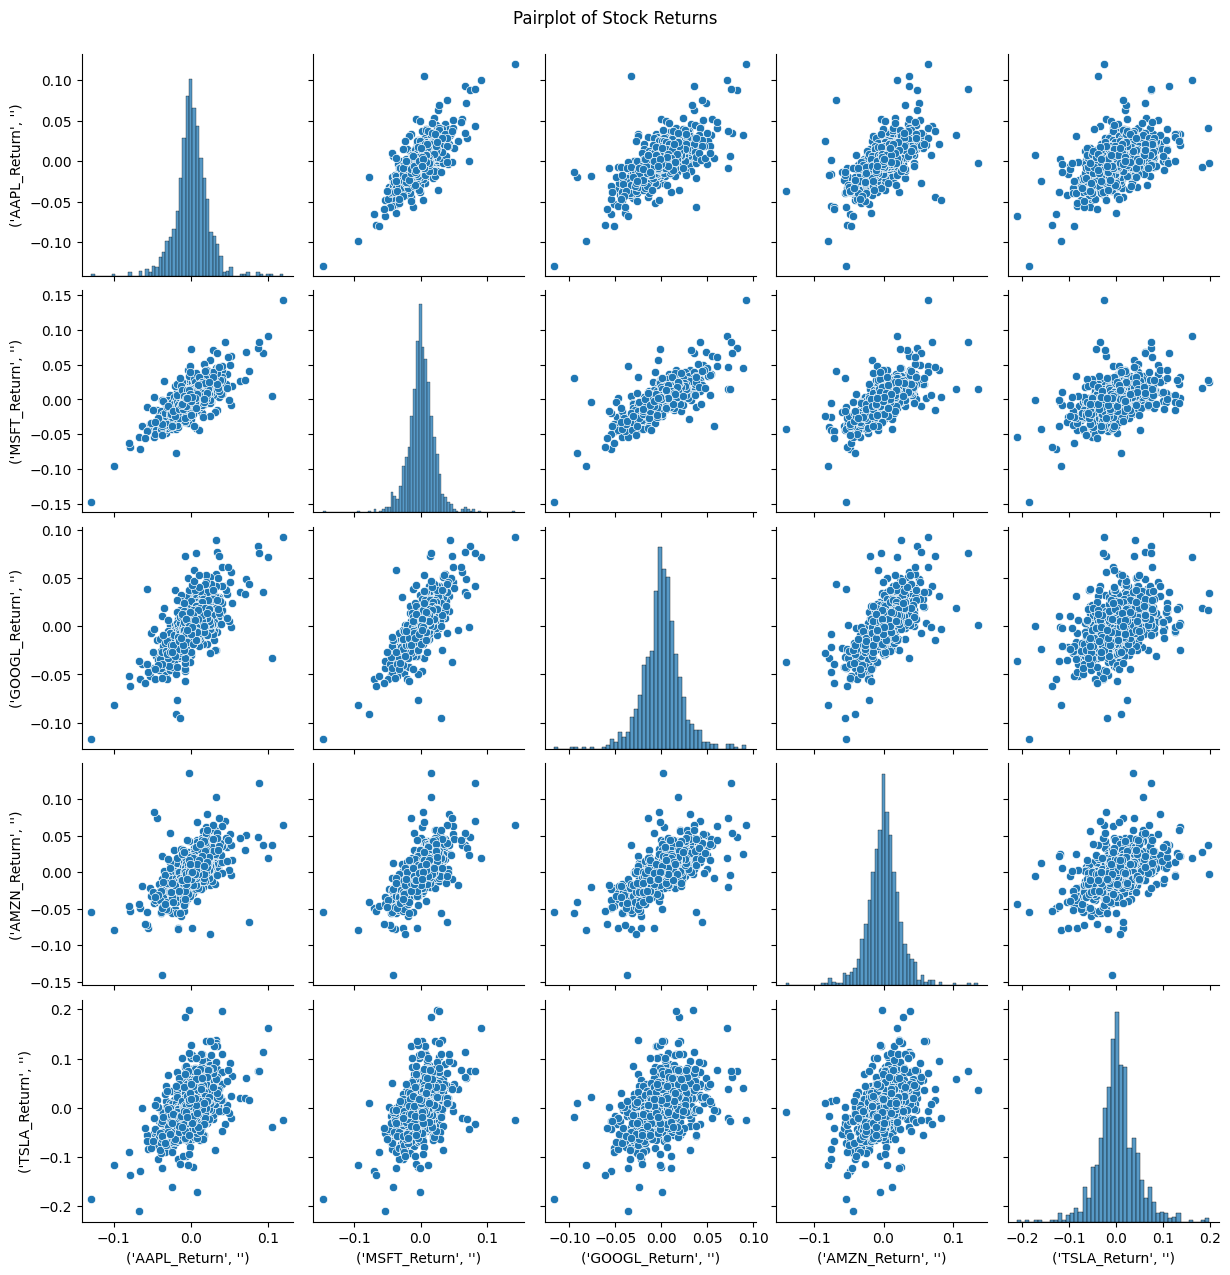

In [17]:
plt.figure(figsize=(10,5))
sns.pairplot(data[[f'{ticker}_Return' for ticker in tickers]])
plt.suptitle("Pairplot of Stock Returns", y=1.02)
plt.show()

#**Modeling**

**Random Forest**

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Feature creation (shifted closing prices as features)
data['Lag_1'] = data['Close']['AAPL'].shift(1)
data.dropna(inplace=True)

# Prepare data for modeling
X = data[['Lag_1']]
y = data['Close']['AAPL']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 77.99655539431592


**Random Forest With More Features**

In [22]:
# Splitting Data for Modeling
selected_ticker = "AAPL"  # Using Apple stock as an example
target = data[f'{selected_ticker}_Return']
features = data[[f'{selected_ticker}_Volatility', f'{selected_ticker}_Momentum', f'{selected_ticker}_Moving_Avg']]
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, shuffle=False)


In [23]:
# Model 1: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
print(f'Random Forest MSE: {rf_mse}')

Random Forest MSE: 0.0001310594543657396


**LSTM Neural Network**

In [24]:
# Model 2: LSTM Neural Network
X_train_lstm = np.reshape(X_train.values, (X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = np.reshape(X_test.values, (X_test.shape[0], X_test.shape[1], 1))

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=16, validation_data=(X_test_lstm, y_test))
y_pred_lstm = lstm_model.predict(X_test_lstm)
lstm_mse = mean_squared_error(y_test, y_pred_lstm)
print(f'LSTM MSE: {lstm_mse}')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0034 - val_loss: 1.4730e-04
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0010 - val_loss: 1.3774e-04
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.4463e-04 - val_loss: 1.4781e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7334e-04 - val_loss: 1.8135e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.5710e-04 - val_loss: 1.6671e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.0329e-04 - val_loss: 1.4409e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.1313e-04 - val_loss: 1.5971e-04
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.7735e-04 - val_loss: 1.4239e-04
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.4790e-04 - val_loss: 1.5165e-04
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.6320e-04 - val_loss: 1.4869e-04
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.6939e-04 - val_loss: 1